Rohith John 24BAD100
Loading datasets...
Creating User-Item Matrix...
Applying SVD with k=50 latent factors...

--- Top 5 Movie Recommendations for User ID 10 ---
                              title  Predictions
230         Schindler's List (1993)     4.574990
65              Blade Runner (1982)     4.516309
129  Godfather: Part II, The (1974)     4.499940
326    To Kill a Mockingbird (1962)     4.483008
339               Birds, The (1963)     4.476351

Evaluation Metrics (k=50):
RMSE: 0.7253
MAE:  0.5566

Generating Visualizations...


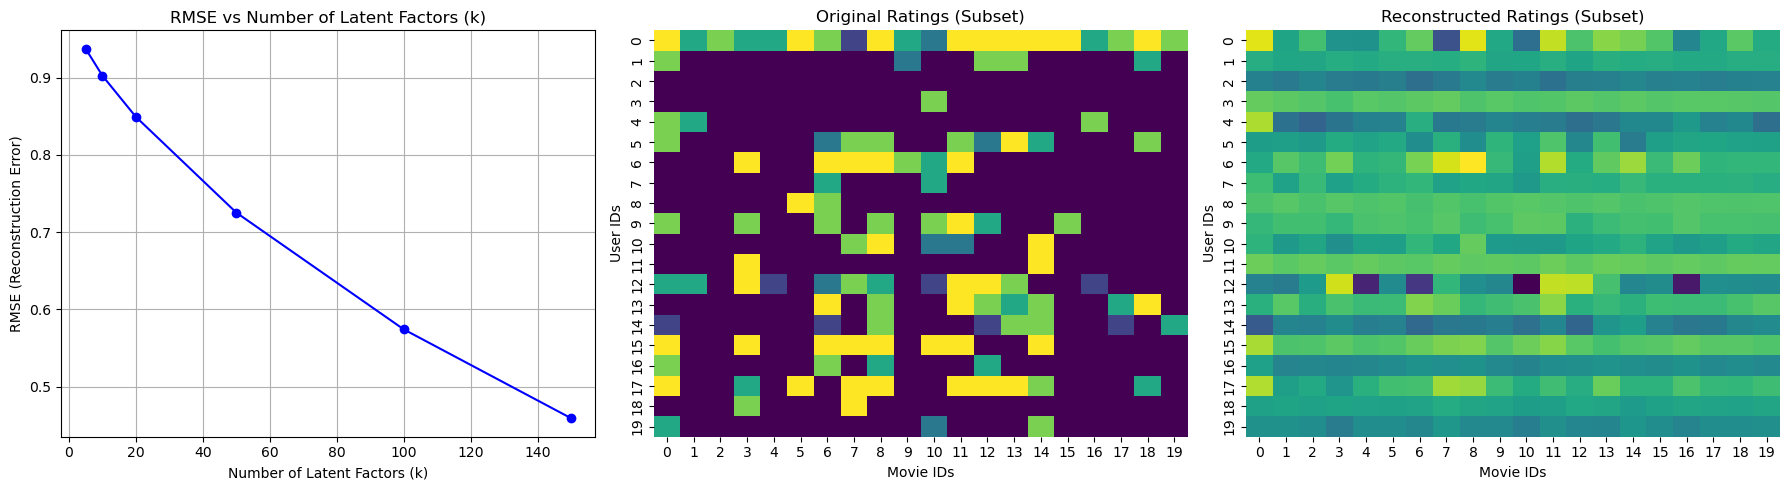

In [ ]:
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Rohith John 24BAD100")
# 2. LOAD THE MOVIELENS DATASET
print("Loading datasets...")
# Using direct URLs to the MovieLens 100k dataset for seamless execution
ratings_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
movies_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'

# Read ratings
ratings = pd.read_csv(ratings_url, sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
# Read movie titles (handling encoding issues common in u.item)
movies = pd.read_csv(movies_url, sep='|', header=None, encoding='latin-1', usecols=[0, 1], names=['movie_id', 'title'])

# 3. PERFORM DATA PREPROCESSING
# Drop timestamp as it is not needed for basic SVD
ratings = ratings.drop('timestamp', axis=1)
# Merge titles with ratings for interpretability
df = pd.merge(ratings, movies, on='movie_id')

# 4. CREATE USER-ITEM INTERACTION MATRIX
print("Creating User-Item Matrix...")
user_item_matrix = df.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)
R = user_item_matrix.values # Convert to NumPy array

# 5. NORMALIZE THE MATRIX (Mean Centering)
# Calculate mean rating per user (ignoring 0s which represent unrated movies)
user_ratings_mean = np.sum(R, axis=1) / np.sum(R > 0, axis=1)
# Subtract the mean from the non-zero ratings
R_demeaned = np.where(R > 0, R - user_ratings_mean.reshape(-1, 1), 0)

# 6 & 7. APPLY SVD DECOMPOSITION & REDUCE DIMENSIONS
k_factors = 50 # Number of latent factors
print(f"Applying SVD with k={k_factors} latent factors...")
# scipy's svds handles sparse matrices and truncation efficiently
U, sigma, Vt = svds(R_demeaned, k=k_factors)

# Convert sigma from a 1D array to a diagonal matrix
sigma = np.diag(sigma)
#Rohith John 24BAD100
# 8. RECONSTRUCT THE MATRIX
# R' = U * Sigma * Vt + user_means
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

# 9. PREDICT MISSING RATINGS
preds_df = pd.DataFrame(predicted_ratings, columns=user_item_matrix.columns, index=user_item_matrix.index)

# 10. GENERATE TOP-N RECOMMENDATIONS
def recommend_movies(preds_df, user_id, movies_df, original_ratings_df, num_recommendations=5):
    # Get and sort the user's predictions
    user_row_number = user_id 
    sorted_user_predictions = preds_df.loc[user_row_number].sort_values(ascending=False)
    
    # Get the user's historical data
    user_data = original_ratings_df[original_ratings_df.user_id == (user_id)]
    
    # Recommend movies the user hasn't seen yet
    recommendations = (movies_df[~movies_df['movie_id'].isin(user_data['movie_id'])]).copy()
    recommendations = recommendations.merge(pd.DataFrame(sorted_user_predictions).reset_index(), on='movie_id')
    recommendations = recommendations.rename(columns={user_row_number: 'Predictions'})
    recommendations = recommendations.sort_values('Predictions', ascending=False).iloc[:num_recommendations]
    
    return recommendations

print("\n--- Top 5 Movie Recommendations for User ID 10 ---")
top_movies = recommend_movies(preds_df, user_id=10, movies_df=movies, original_ratings_df=ratings, num_recommendations=5)
print(top_movies[['title', 'Predictions']])

# ==========================================
# EVALUATION METRICS
# ==========================================
# We only evaluate the error on the non-zero elements (actual ratings)
actual_ratings = R[R.nonzero()]
predicted_ratings_masked = predicted_ratings[R.nonzero()]

rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings_masked))
mae = mean_absolute_error(actual_ratings, predicted_ratings_masked)
print(f"\nEvaluation Metrics (k={k_factors}):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# ==========================================
# ANALYSIS & VISUALIZATION
print("\nGenerating Visualizations...")

plt.figure(figsize=(18, 5))

# 1. Error vs Number of Latent Factors (k)
# Simulating the effect of different k values
k_values = [5, 10, 20, 50, 100, 150]
rmse_values = []

for k in k_values:
    U_k, sigma_k, Vt_k = svds(R_demeaned, k=k)
    pred_k = np.dot(np.dot(U_k, np.diag(sigma_k)), Vt_k) + user_ratings_mean.reshape(-1, 1)
    rmse_k = np.sqrt(mean_squared_error(R[R.nonzero()], pred_k[R.nonzero()]))
    rmse_values.append(rmse_k)

plt.subplot(1, 3, 1)
plt.plot(k_values, rmse_values, marker='o', linestyle='-', color='b')
plt.title('RMSE vs Number of Latent Factors (k)')
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('RMSE (Reconstruction Error)')
plt.grid(True)

# 2. Heatmap of Original Matrix (Subset)
# We take a 20x20 subset because the full 943x1682 matrix is too large to plot effectively
subset_size = 20
plt.subplot(1, 3, 2)
sns.heatmap(R[:subset_size, :subset_size], cmap='viridis', cbar=False)
plt.title('Original Ratings (Subset)')
plt.xlabel('Movie IDs')
plt.ylabel('User IDs')

# 3. Heatmap of Reconstructed Matrix (Subset)
plt.subplot(1, 3, 3)
sns.heatmap(predicted_ratings[:subset_size, :subset_size], cmap='viridis', cbar=False)
plt.title('Reconstructed Ratings (Subset)')
plt.xlabel('Movie IDs')
plt.ylabel('User IDs')

plt.tight_layout()
plt.show()

Rohtih John 24BAD100
Loading MovieLens dataset...
Creating User-Item Matrix...
Applying NMF with k=20 latent features...
Reconstructing matrix...

--- Top 5 Recommendations for User ID 15 ---
              title  Predicted_Rating
0      Fargo (1996)          3.426535
1  Rock, The (1996)          2.810096
2  Lone Star (1996)          2.543090
3  Liar Liar (1997)          2.500920
4    Titanic (1997)          2.066719

RMSE: 2.2274
Precision@10: 0.5721
Recall@10:    0.0595

Generating Visualizations...


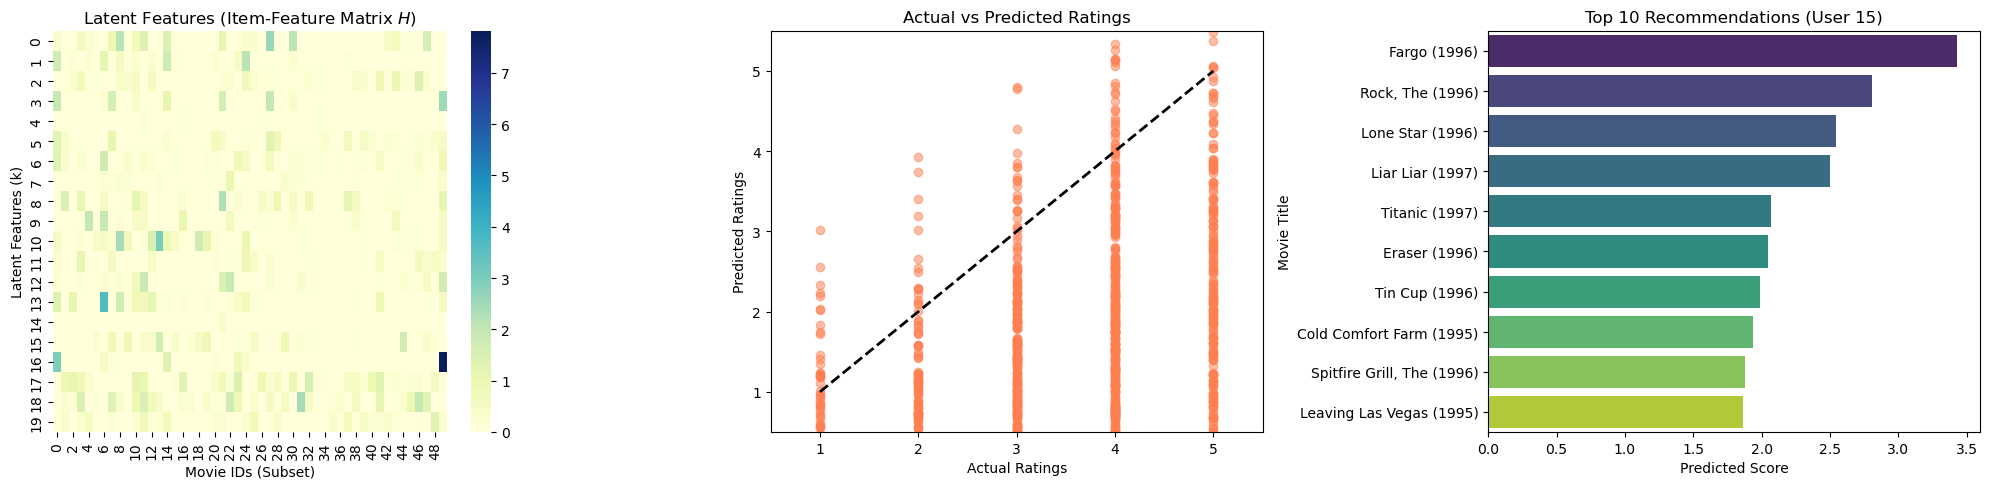

In [ ]:
# ==========================================
# SCENARIO 2: MATRIX FACTORIZATION USING NMF]
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
print("Rohtih John 24BAD100")
# 2. LOAD DATASET
print("Loading MovieLens dataset...")
ratings_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
movies_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'

ratings = pd.read_csv(ratings_url, sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv(movies_url, sep='|', header=None, encoding='latin-1', usecols=[0, 1], names=['movie_id', 'title'])

# Drop timestamp and merge
ratings = ratings.drop('timestamp', axis=1)
df = pd.merge(ratings, movies, on='movie_id')

# 3. CREATE USER-ITEM MATRIX & HANDLE MISSING VALUES
print("Creating User-Item Matrix...")
# NMF requires non-negative values. We fill missing interactions with 0.
user_item_matrix = df.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)
R = user_item_matrix.values

# 4 & 5. APPLY NMF MODEL & FACTORIZE
k_factors = 20 # Number of latent features
print(f"Applying NMF with k={k_factors} latent features...")

# Initialize NMF. init='nndsvd' is better for sparse matrices than random.
nmf_model = NMF(n_components=k_factors, init='nndsvd', random_state=42, max_iter=200)

# a. User-feature matrix (W)
W = nmf_model.fit_transform(R) 

# b. Item-feature matrix (H)
H = nmf_model.components_      
#Rohith John 24BAD100
# 6. RECONSTRUCT THE RATING MATRIX
print("Reconstructing matrix...")
# R' = W * H
predicted_ratings = np.dot(W, H)

# 7. PREDICT MISSING VALUES
preds_df = pd.DataFrame(predicted_ratings, columns=user_item_matrix.columns, index=user_item_matrix.index)

# 8. GENERATE TOP-N RECOMMENDATIONS
def get_top_n_recommendations(preds_df, user_id, movies_df, original_matrix, num_recommendations=5):
    sorted_user_predictions = preds_df.loc[user_id].sort_values(ascending=False)
    
    # Get items the user has already rated
    user_history = original_matrix.loc[user_id]
    rated_items = user_history[user_history > 0].index.tolist()
    
    # Filter out already rated items
    recommendations = sorted_user_predictions.drop(labels=rated_items).head(num_recommendations)
    
    # Map back to titles
    rec_df = pd.DataFrame(recommendations).reset_index()
    rec_df.columns = ['movie_id', 'Predicted_Rating']
    rec_df = rec_df.merge(movies_df, on='movie_id')
    return rec_df[['title', 'Predicted_Rating']]

target_user = 15
print(f"\n--- Top 5 Recommendations for User ID {target_user} ---")
print(get_top_n_recommendations(preds_df, target_user, movies, user_item_matrix, 5))

# ==========================================
# EVALUATION METRICS
# ==========================================
# RMSE Calculation (on non-zero elements)
actual_ratings = R[R.nonzero()]
predicted_ratings_masked = predicted_ratings[R.nonzero()]
rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings_masked))
print(f"\nRMSE: {rmse:.4f}")

# Precision@K and Recall@K Calculation
def precision_recall_at_k(predictions, actuals, k=10, threshold=3.5):
    """Calculates P@K and R@K evaluating over the reconstructed matrix."""
    user_est_true = defaultdict(list)
    for u in range(actuals.shape[0]):
        for i in range(actuals.shape[1]):
            if actuals[u, i] > 0: # Only evaluate where we have ground truth
                user_est_true[u].append((predictions[u, i], actuals[u, i]))
                
    precisions = dict()
    recalls = dict()
    
    for uid, user_ratings in user_est_true.items():
        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])
        
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return sum(precisions.values()) / len(precisions), sum(recalls.values()) / len(recalls)
#Rohith John 24BAD100
precision, recall = precision_recall_at_k(predicted_ratings, R, k=10, threshold=3.5)
print(f"Precision@10: {precision:.4f}")
print(f"Recall@10:    {recall:.4f}")

# ==========================================
# VISUALIZATIONS
# ==========================================
print("\nGenerating Visualizations...")
plt.figure(figsize=(20, 5))

# 1. Latent Feature Visualization (Item-Feature Matrix H)
plt.subplot(1, 3, 1)
# Visualizing the first 50 movies across the 20 latent features
sns.heatmap(H[:, :50], cmap='YlGnBu', cbar=True)
plt.title('Latent Features (Item-Feature Matrix $H$)')
plt.xlabel('Movie IDs (Subset)')
plt.ylabel('Latent Features (k)')

# 2. Reconstruction Comparison
plt.subplot(1, 3, 2)
# Scatter plot of Actual vs Predicted for a random sample of 1000 known ratings
sample_indices = np.random.choice(len(actual_ratings), 1000, replace=False)
plt.scatter(actual_ratings[sample_indices], predicted_ratings_masked[sample_indices], alpha=0.5, color='coral')
plt.plot([1, 5], [1, 5], 'k--', lw=2) # Ideal line
plt.title('Actual vs Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)

# 3. Recommendation Ranking Chart
plt.subplot(1, 3, 3)
top_recs = get_top_n_recommendations(preds_df, target_user, movies, user_item_matrix, 10)
sns.barplot(x='Predicted_Rating', y='title', data=top_recs, palette='viridis')
plt.title(f'Top 10 Recommendations (User {target_user})')
plt.xlabel('Predicted Score')
plt.ylabel('Movie Title')

plt.tight_layout()
plt.show()